In [3]:
#load libraries
library(dplyr)
library(tidyverse)
library(ggplot2)
library(car)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: carData




Attaching package: ‘car’




The following object is masked from ‘package:purrr’:

    some




The following object is masked from ‘package:dplyr’:

    recode




In [16]:
# set working directory
setwd("/home/user/Capstone/data_center_research_r/")
getwd()

# List all files in the current working directory
list.files()

# List the files in the data/processed/ directory
list.files("/home/user/Capstone/data_center_research_r/data/processed/")

[1] "/home/user/Capstone/data_center_research_r"

[1] "data"    "scripts"

[1] "PEC_table-1.csv" "README.txt"

In [17]:
# Import CSV file
data_center_df <- read.csv("/home/user/Capstone/data_center_research_r/data/processed/PEC_table-1.csv")

# show first 10 rows
head(data_center_df,10)

,OBJECTID,PEC_ID,Locality,Name,Owner_Applicant,Street_Address,Parcel_ID,Acres,Building_Sq_Ft,MW_reported,⋯,Build_Status,Notes,Tax_Map_link,Source_link,Lat,Long,Date_Updated,Updated_By,Lat1,Watershed
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<lgl>
1,1,PEC-CAR-0001/PEC-SPO-0003,Caroline County,Mattameade Tech Campus,Amazon Data Services Inc,Stonewall Jackson Road just east of the Mudd Tavern,27-A-4A,916.07,"4,500,000",NA,⋯,Proposed,Sister property to Spotsylvania campus- represents total square footage,,https://co.caroline.va.us/DocumentCenter/View/7255/RZ-02-2023-Orrock-Tech-Camus?bidId=,38.11465,-77.49115,2024-04-10,SEP,38.11465,NA
2,2,PEC-CAR-0002,Caroline County,VALCO Data Center Park,VALCO CAROLINE COUNTY,Mt Airy Road,80-A-43,855.00,"1,216,000",NA,⋯,Proposed,"Project covers more than one parcel, the acreage represents the combined acreage",,https://co.caroline.va.us/AgendaCenter/ViewFile/Item/5593?fileID=9447,37.92410,-77.54387,2024-04-10,SEP,37.92410,NA
3,3,PEC-CAR-0003,Caroline County,Carmel Church Data Hub,W & F PARTNERS,Welcom Way Dr,82-14-A,97.00,"1,600,000",NA,⋯,Proposed,"Project covers more than one parcel, the acreage represents the combined acreage",,https://co.caroline.va.us/DocumentCenter/View/9366/RZ-03-2023--Carmel-Church-Data-Hub,37.93933,-77.47797,2024-04-10,SEP,37.93933,NA
4,4,PEC-CHE-0001,Chesterfield County,Digital Fortress: Richmond,CHIRISA RICHMOND LLC,1401 MEADOWVILLE TECH PARKWAY,823657720300000,74.80,"242,042",25,⋯,Existing,Formerly a Capital One data center - vacated and for sale,https://www.chesterfield.gov/828/Real-Estate-Assessment-Data#/Details/823657720300000,,37.36048,-77.32741,2024-04-10,SEP,37.36048,NA
5,5,PEC-CHE-0002,Chesterfield County,Virginia Information Technologies Agency,SLK GLOBAL SOLUTIONS AMERICA,11751 MEADOWVILLE LANE,822656429800000,28.14,"192,195",NA,⋯,Existing,,https://www.chesterfield.gov/828/Real-Estate-Assessment-Data#/Details/822656429800000,,37.36041,-77.33178,2024-04-10,SEP,37.36041,NA
6,6,PEC-CUL-0001,Culpeper County,Equinix,EQUINIX LLC,18155 TECHNOLOGY DR,51-83A1,30.12,"370,000",NA,⋯,Existing,,https://gis.vgsi.com/culpeperva/Parcel.aspx?pid=10680,,38.45494,-77.97828,2024-04-10,SEP,38.45494,NA
7,7,PEC-CUL-0002,Culpeper County,SWIFT,,,51 83F,NA,"90,000",NA,⋯,Existing,,,,38.45554,-77.98348,2024-04-10,SEP,38.45554,NA
8,8,PEC-CUL-0003,Culpeper County,Cielo Digital Infrastructure,Cielo Digital Infrastructure,Cielo Digital Infrastructure,41-110,120.89,"1,400,000",NA,⋯,Proposed,"Project covers more than one parcel, the acreage represents the combined acreage",https://gis.vgsi.com/culpeperva/Parcel.aspx?pid=3148,http://go.boarddocs.com/va/ccva/Board.nsf/goto?open&id=CWBKLL525B17,38.46679,-77.96353,2024-04-10,SEP,38.46679,NA
9,9,PEC-CUL-0004,Culpeper County,CloudHQ,CloudHQ,14521 MCDEVITT DR,41-106D,98.56,"2,100,000",NA,⋯,Proposed,"Project covers more than one parcel, the acreage represents the combined acreage",https://gis.vgsi.com/culpeperva/Parcel.aspx?pid=21853,"https://www.culpeperva.org/properties/cloudhq-culpeper/#:~:text=CloudHQ%2C%20a%20global%20data%20center,of%20critical%20IT%20load%20power.",38.46164,-77.97762,2024-04-10,SEP,38.46164,NA


In [18]:
# Get the dimensitons of the dataframe
dim(data_center_df)

#What are the variables of the dataset
names(data_center_df)

#What data types were created
str(data_center_df)

[1] 416  21

[1] "OBJECTID"          "PEC_ID"            "Locality"         
 [4] "Name"              "Owner_Applicant"   "Street_Address"   
 [7] "Parcel_ID"         "Acres"             "Building_Sq_Ft"   
[10] "MW_reported"       "Construction_Type" "Build_Status"     
[13] "Notes"             "Tax_Map_link"      "Source_link"      
[16] "Lat"               "Long"              "Date_Updated"     
[19] "Updated_By"        "Lat1"              "Watershed"

'data.frame':	416 obs. of  21 variables:
 $ OBJECTID         : int  1 2 3 4 5 6 7 8 9 10 ...
 $ PEC_ID           : chr  "PEC-CAR-0001/PEC-SPO-0003" "PEC-CAR-0002" "PEC-CAR-0003" "PEC-CHE-0001" ...
 $ Locality         : chr  "Caroline County" "Caroline County" "Caroline County" "Chesterfield County" ...
 $ Name             : chr  "Mattameade Tech Campus" "VALCO Data Center Park" "Carmel Church Data Hub" "Digital Fortress: Richmond" ...
 $ Owner_Applicant  : chr  "Amazon Data Services Inc" "VALCO CAROLINE COUNTY" "W & F PARTNERS" "CHIRISA RICHMOND LLC" ...
 $ Street_Address   : chr  "Stonewall Jackson Road just east of the Mudd Tavern" "Mt Airy Road" "Welcom Way Dr" "1401 MEADOWVILLE TECH PARKWAY" ...
 $ Parcel_ID        : chr  "27-A-4A" "80-A-43" "82-14-A" "823657720300000" ...
 $ Acres            : num  916.1 855 97 74.8 28.1 ...
 $ Building_Sq_Ft   : chr  "4,500,000" "1,216,000" "1,600,000" "242,042" ...
 $ MW_reported      : num  NA NA NA 25 NA NA NA NA NA NA ...
 $ Construction_Type

In [19]:
#Create new dataframe
data_center_clean <- as.data.frame(data_center_df)

#Rename variables
data_center_clean <- data_center_clean %>%
  rename(
    object_id = OBJECTID,
    pec_id = PEC_ID,
    locality = Locality,
    name = Name,
    owner_applicant = Owner_Applicant,
    street_address = Street_Address,
    parcel_id = Parcel_ID,
    acres = Acres,
    building_sq_ft = Building_Sq_Ft,
    mw_reported = MW_reported,
    construction_type = Construction_Type,
    build_status = Build_Status,
    notes = Notes,
    tax_map_link = Tax_Map_link,
    source_link = Source_link,
    lat = Lat,
    long = Long,
    date_updated = Date_Updated,
    updated_by = Updated_By,
    lat1 = Lat1,
    watershed = Watershed,
  )

#list the renames
names(data_center_clean)


[1] "object_id"         "pec_id"            "locality"         
 [4] "name"              "owner_applicant"   "street_address"   
 [7] "parcel_id"         "acres"             "building_sq_ft"   
[10] "mw_reported"       "construction_type" "build_status"     
[13] "notes"             "tax_map_link"      "source_link"      
[16] "lat"               "long"              "date_updated"     
[19] "updated_by"        "lat1"              "watershed"

In [20]:
#glimpse
glimpse(data_center_clean)

Rows: 416
Columns: 21
$ object_id         <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 1…
$ pec_id            <chr> "PEC-CAR-0001/PEC-SPO-0003", "PEC-CAR-0002", "PEC-CA…
$ locality          <chr> "Caroline County", "Caroline County", "Caroline Coun…
$ name              <chr> "Mattameade Tech Campus", "VALCO Data Center Park", …
$ owner_applicant   <chr> "Amazon Data Services Inc", "VALCO CAROLINE COUNTY",…
$ street_address    <chr> "Stonewall Jackson Road just east of the Mudd Tavern…
$ parcel_id         <chr> "27-A-4A", "80-A-43", "82-14-A", "823657720300000", …
$ acres             <dbl> 916.07, 855.00, 97.00, 74.80, 28.14, 30.12, NA, 120.…
$ building_sq_ft    <chr> "4,500,000", "1,216,000", "1,600,000", "242,042", "1…
$ mw_reported       <dbl> NA, NA, NA, 25, NA, NA, NA, NA, NA, NA, NA, NA, NA, …
$ construction_type <chr> "New", "New", "New", "Complete", "Complete", "Comple…
$ build_status      <chr> "Proposed", "Proposed", "Proposed", "Existing", "Exi…
$ notes           

In [21]:
# Clean the 'building_sq_ft' column by removing commas or other unwanted characters
data_center_clean <- data_center_clean %>%
    mutate(building_sq_ft = gsub(",", "", building_sq_ft)) %>%  # Remove commas
    mutate(building_sq_ft = as.numeric(building_sq_ft))  # Convert to numeric

# Check the structure again
str(data_center_clean)


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `building_sq_ft = as.numeric(building_sq_ft)`.
Caused by warning:
! NAs introduced by coercion”


'data.frame':	416 obs. of  21 variables:
 $ object_id        : int  1 2 3 4 5 6 7 8 9 10 ...
 $ pec_id           : chr  "PEC-CAR-0001/PEC-SPO-0003" "PEC-CAR-0002" "PEC-CAR-0003" "PEC-CHE-0001" ...
 $ locality         : chr  "Caroline County" "Caroline County" "Caroline County" "Chesterfield County" ...
 $ name             : chr  "Mattameade Tech Campus" "VALCO Data Center Park" "Carmel Church Data Hub" "Digital Fortress: Richmond" ...
 $ owner_applicant  : chr  "Amazon Data Services Inc" "VALCO CAROLINE COUNTY" "W & F PARTNERS" "CHIRISA RICHMOND LLC" ...
 $ street_address   : chr  "Stonewall Jackson Road just east of the Mudd Tavern" "Mt Airy Road" "Welcom Way Dr" "1401 MEADOWVILLE TECH PARKWAY" ...
 $ parcel_id        : chr  "27-A-4A" "80-A-43" "82-14-A" "823657720300000" ...
 $ acres            : num  916.1 855 97 74.8 28.1 ...
 $ building_sq_ft   : num  4500000 1216000 1600000 242042 192195 ...
 $ mw_reported      : num  NA NA NA 25 NA NA NA NA NA NA ...
 $ construction_type: chr  "

In [22]:
#check if data_center_clean is a function or a dataset
class(data_center_clean)


[1] "data.frame"

In [26]:
# Check the column names in the data frame
colnames(data_center_clean)

# Filter for Loudoun County and construction_type == "Complete"
data_center_filtered <- data_center_clean %>%
    filter(locality == "Loudoun County", construction_type == "Complete") %>%  # Filter first
    select(locality, name, owner_applicant, acres, building_sq_ft, construction_type, build_status, lat, long) %>%  # Select relevant columns
    group_by(construction_type) %>%  # Group by construction_type
    summarise(count = n())  # Get the count of rows in each group

# View the filtered and summarized data
head(data_center_filtered)




[1] "object_id"         "pec_id"            "locality"         
 [4] "name"              "owner_applicant"   "street_address"   
 [7] "parcel_id"         "acres"             "building_sq_ft"   
[10] "mw_reported"       "construction_type" "build_status"     
[13] "notes"             "tax_map_link"      "source_link"      
[16] "lat"               "long"              "date_updated"     
[19] "updated_by"        "lat1"              "watershed"

construction_type,count
<chr>,<int>
Complete,108


In [27]:
# Filter for Loudoun County and construction_type == "Complete", then select specific columns
data_center_filtered <- data_center_clean %>%
    filter(locality == "Loudoun County", construction_type == "Complete") %>%  # Filter rows
    select(locality, name, owner_applicant, acres, building_sq_ft, construction_type, build_status, lat, long)  # Select columns

# View the filtered data
head(data_center_filtered)


,locality,name,owner_applicant,acres,building_sq_ft,construction_type,build_status,lat,long
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
1,Loudoun County,NV-8 CYRUSONE,C1 NORTHERN VIRGINIA - STERLING VIII LLC,9.68,154100,Complete,Existing,39.02125,-77.41337
2,Loudoun County,CYXTERA DC2 COLOCATION,MEDINA DC 2 ASSETS LLC,6.24,89072,Complete,Existing,39.02325,-77.41318
3,Loudoun County,MARIES TECH PARK LLC,Amazon Data Services Inc,19.50,426710,Complete,Existing,39.02400,-77.41950
4,Loudoun County,45845 NOKES BLVD,MEDINA DC 2 ASSETS LLC,6.02,79300,Complete,Existing,39.02387,-77.41527
5,Loudoun County,C1 NORTHERN VA - STERLING I-III,CyrusOne,14.34,420000,Complete,Existing,39.02607,-77.41454
6,Loudoun County,CYXTERA COLOCATION,MEDINA DC 2 ASSETS LLC,8.49,135500,Complete,Existing,39.02480,-77.41233


In [34]:
# Assuming the following values
impervious_pct <- 0.85    # 85% impervious area
rain_intensity <- 2.5     # Rainfall intensity (in inches per hour)
C_value <- 0.85          # Runoff coefficient for impervious surfaces

# Create an empty data frame to store results
results <- data.frame(
  name = character(),           # To store data center names
  building_sq_ft = numeric(),   # To store building square footage
  impervious_area = numeric(),  # To store impervious area
  runoff = numeric()            # To store calculated runoff
)

# Iterate through each data center row
for (i in 1:nrow(data_center_filtered)) {
  # Get the name and building square footage for the current data center
  name <- data_center_filtered$name[i]
  building_sq_ft <- data_center_filtered$building_sq_ft[i]
  
# Calculate impervious area and runoff (using the Rational Method), and add these to the data frame
data_center_filtered <- data_center_filtered %>%
  mutate(
    impervious_area = building_sq_ft * impervious_pct,  # Impervious area (sq ft)
    runoff = C_value * rain_intensity * impervious_area  # Runoff (cubic feet per hour)
  )

  # Add the result to the 'results' data frame
  results <- rbind(results, data.frame(
    name = name,
    building_sq_ft = building_sq_ft,
    impervious_area = impervious_area,
    runoff = runoff
  ))
}

# Check if the runoff column is added correctly
str(data_center_filtered$runoff)

# Check the structure of the entire data_center_filtered data frame
str(data_center_filtered)




 num [1:108] 278343 160886 770745 143236 758625 ...


'data.frame':	108 obs. of  11 variables:
 $ locality         : chr  "Loudoun County" "Loudoun County" "Loudoun County" "Loudoun County" ...
 $ name             : chr  "NV-8 CYRUSONE" "CYXTERA DC2 COLOCATION" "MARIES TECH PARK LLC" "45845 NOKES BLVD" ...
 $ owner_applicant  : chr  "C1 NORTHERN VIRGINIA - STERLING VIII LLC" "MEDINA DC 2 ASSETS LLC" "Amazon Data Services Inc" "MEDINA DC 2 ASSETS LLC" ...
 $ acres            : num  9.68 6.24 19.5 6.02 14.34 ...
 $ building_sq_ft   : num  154100 89072 426710 79300 420000 ...
 $ construction_type: chr  "Complete" "Complete" "Complete" "Complete" ...
 $ build_status     : chr  "Existing" "Existing" "Existing" "Existing" ...
 $ lat              : num  39 39 39 39 39 ...
 $ long             : num  -77.4 -77.4 -77.4 -77.4 -77.4 ...
 $ impervious_area  : num  130985 75711 362704 67405 357000 ...
 $ runoff           : num  278343 160886 770745 143236 758625 ...


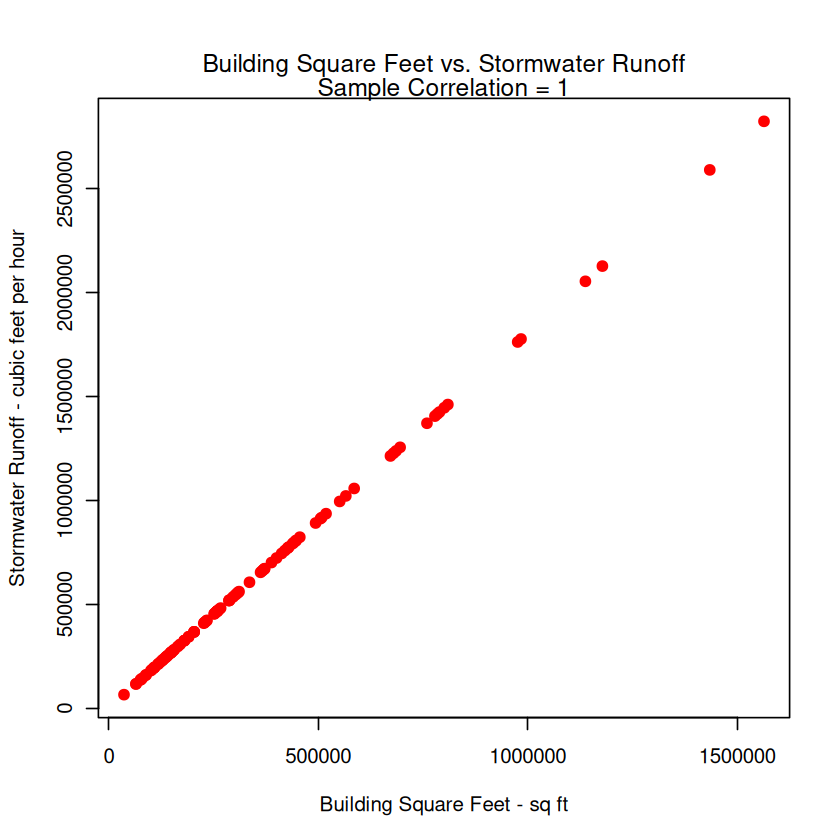

In [39]:
#Plot a scatterplot of the building_sq_ft and imperious_area variables for each of the 108 data centers in Loudoun County

plot(data_center_filtered$building_sq_ft, data_center_filtered$runoff, pch = 19, col = "red", xlab = "Building Square Feet - sq ft",
     ylab = "Stormwater Runoff - cubic feet per hour")
mtext(paste("Sample Correlation =", round(cor(data_center_filtered$building_sq_ft, data_center_filtered$runoff, use = "complete.obs"), 3)), cex = 1.2, line = 0)
mtext("Building Square Feet vs. Stormwater Runoff", cex = 1.2, line = 1)

[1] 66 91

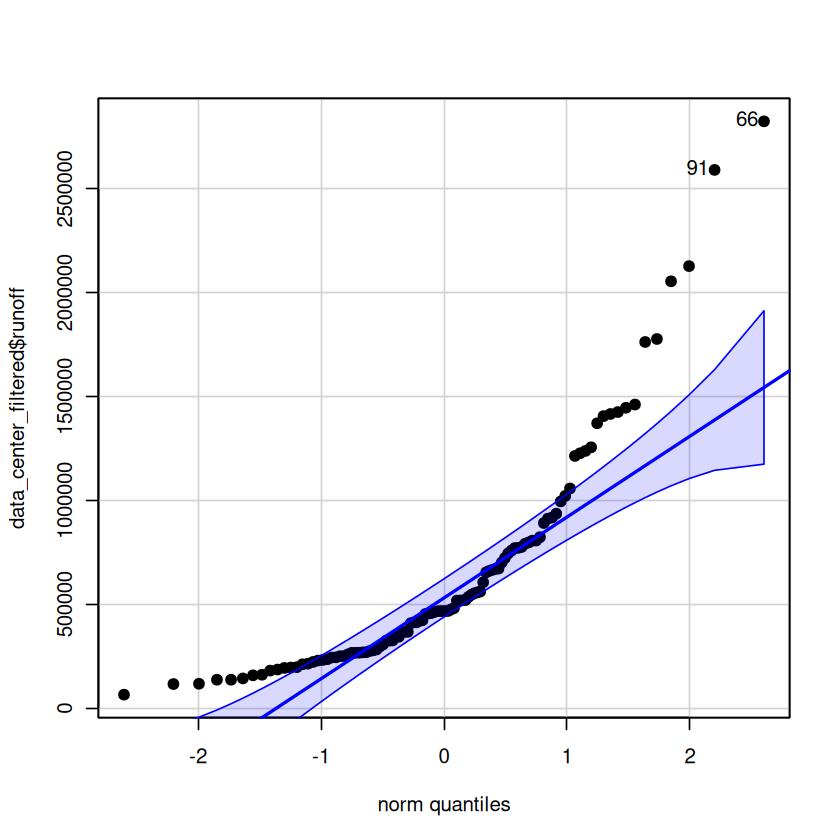

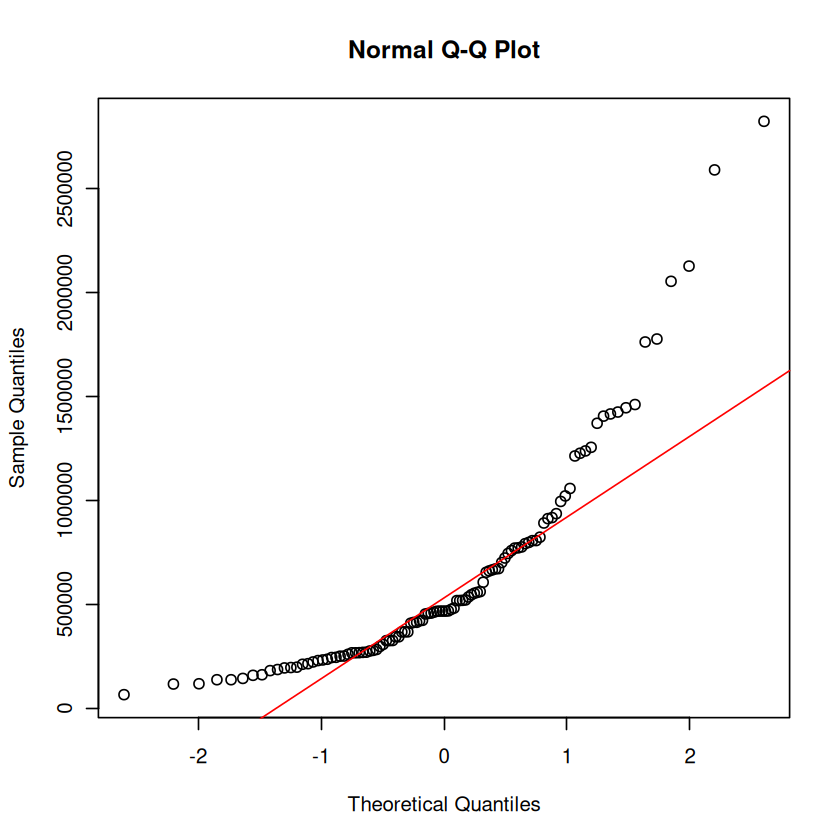

In [42]:
#take a normal-quantile plot using qq() in the car package
qqp(data_center_filtered$runoff, pch = 19)    


qqnorm(data_center_filtered$runoff)   # Q-Q plot to compare runoff data with a normal distribution
qqline(data_center_filtered$runoff, col = "red")   # Add a reference line
